# Phase 1 KNN 

## Objective
Compare Flatten, PCA, and HOG feature representations for binary MNIST classification with KNN.

## What This Notebook Shows
1. Load the MNIST dataset and filter it into two target classes  
2. Inspect class distribution and visualize sample images  
3. Apply preprocessing and prepare train/test splits  
4. Compare Flatten, PCA, and HOG feature extraction methods  
5. Train and tune KNN using different values of K  
6. Evaluate results using accuracy, confusion matrix, and error analysis  
7. Identify and present the best-performing configuration

## 1) Environment Setup and Imports

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, repo_root)

from src.utils.mnist_features import  load_mnist, select_binary_classes, split_data, balance_binary_classes, normalize_data, build_features, class_distribution
from src.utils.evaluation import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, per_class_accuracy
from src.models.knn_model import KNNClassifier, grid_search_knn

In [2]:
# Explicit experiment config
RANDOM_STATE = 42
DATA_PATH = "../../data/mnist.npz"

CLASS_A = 0
CLASS_B = 1
TEST_SIZE = 0.15
VAL_SIZE = 0.15

# Optional class-imbalance handling (applied on train split only).
APPLY_CLASS_BALANCING = False
BALANCE_METHOD = "undersample"  # undersample | oversample

FEATURES = ["flatten", "pca", "hog"]
K_VALUES = [1, 3, 5, 7, 9]

print("RANDOM_STATE:", RANDOM_STATE)
print("CLASSES:", (CLASS_A, CLASS_B))
print("FEATURES:", FEATURES)
print("K_VALUES:", K_VALUES)
print("DATA_PATH:", DATA_PATH)
print("APPLY_CLASS_BALANCING:", APPLY_CLASS_BALANCING)
print("BALANCE_METHOD:", BALANCE_METHOD)

RANDOM_STATE: 42
CLASSES: (0, 1)
FEATURES: ['flatten', 'pca', 'hog']
K_VALUES: [1, 3, 5, 7, 9]
DATA_PATH: ../../data/mnist.npz
APPLY_CLASS_BALANCING: False
BALANCE_METHOD: undersample


## 2) Load and Inspect MNIST Dataset

Full dataset shape: (70000, 28, 28), Labels shape: (70000,)
Binary subset (classes 0 & 1): 14780 samples
Class distribution: {0: 6903, 1: 7877}


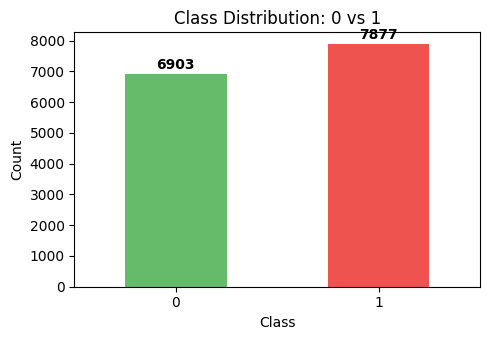

In [3]:
# Load the full MNIST dataset
x_all, y_all = load_mnist('../../data/mnist.npz')
print(f'Full dataset shape: {x_all.shape}, Labels shape: {y_all.shape}')

x_binary, y_binary = select_binary_classes(x_all, y_all, CLASS_A, CLASS_B)
print(f'Binary subset (classes {CLASS_A} & {CLASS_B}): {x_binary.shape[0]} samples')
print('Class distribution:', class_distribution(y_binary))

label_counts = pd.Series(y_binary).value_counts().reindex([CLASS_A, CLASS_B], fill_value=0)

plt.figure(figsize=(5, 3.5))
ax = label_counts.plot(kind='bar', color=['#66bb6a', '#ef5350'], rot=0)
for bar in ax.patches:
    height = bar.get_height()
    ax.text( bar.get_x() + bar.get_width() / 2, height + max(label_counts) * 0.01, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold' )
plt.title(f'Class Distribution: {CLASS_A} vs {CLASS_B}')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

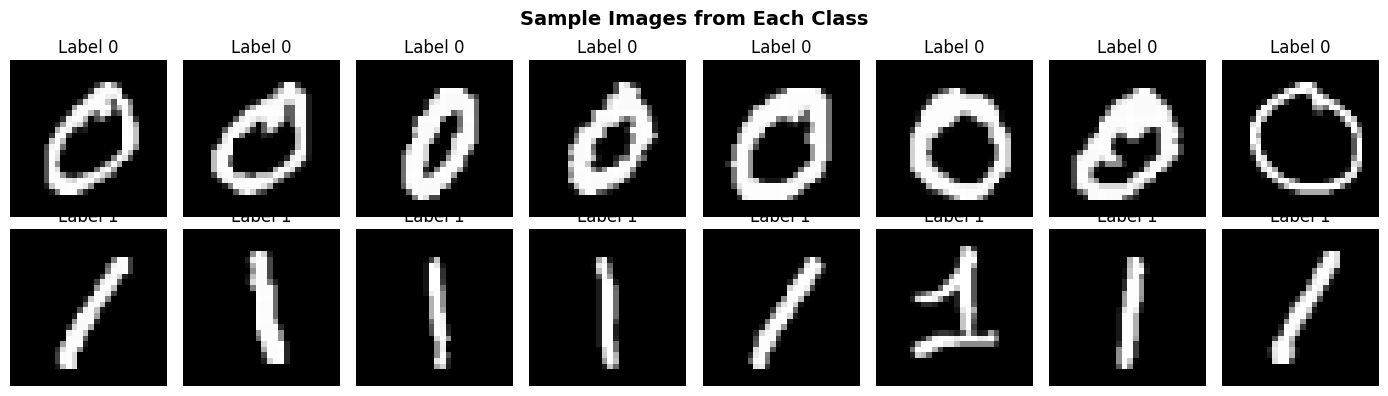

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, label in enumerate([CLASS_A, CLASS_B]):
    idxs = np.where(y_binary == label)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(x_binary[idx], cmap='gray')
        axes[row, col].set_title(f'Label {label}')
        axes[row, col].axis('off')
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Train: 10346,  Val: 2217,  Test: 2217
Train distribution: {0: 4764, 1: 5582}
Val distribution: {0: 1085, 1: 1132}
Test distribution: {0: 1054, 1: 1163}


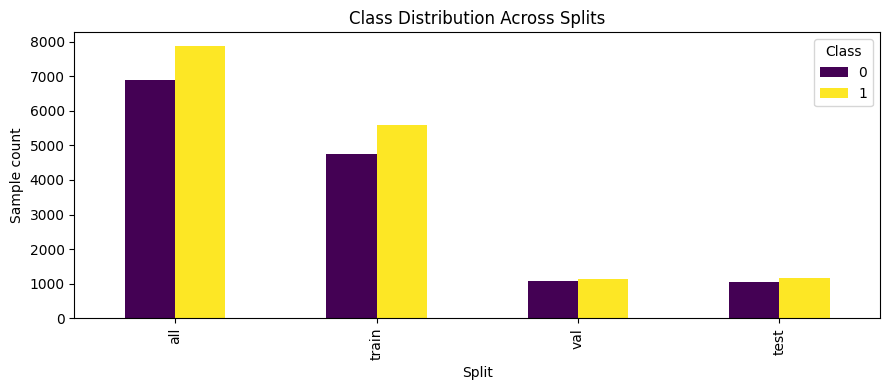

In [5]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(
    x_binary, y_binary, TEST_SIZE, VAL_SIZE, RANDOM_STATE
)

print(f'Train: {len(y_train)},  Val: {len(y_val)},  Test: {len(y_test)}')
print('Train distribution:', class_distribution(y_train))
print('Val distribution:', class_distribution(y_val))
print('Test distribution:', class_distribution(y_test))

# Visualization 
counts_all = class_distribution(y_binary)
counts_train = class_distribution(y_train)
counts_val = class_distribution(y_val)
counts_test = class_distribution(y_test)

split_df = pd.DataFrame(
    {
        'all': [counts_all.get(CLASS_A, 0), counts_all.get(CLASS_B, 0)],
        'train': [counts_train.get(CLASS_A, 0), counts_train.get(CLASS_B, 0)],
        'val': [counts_val.get(CLASS_A, 0), counts_val.get(CLASS_B, 0)],
        'test': [counts_test.get(CLASS_A, 0), counts_test.get(CLASS_B, 0)],
    },
    index=[CLASS_A, CLASS_B],
)

ax = split_df.T.plot(kind='bar', figsize=(9, 4), colormap='viridis')
ax.set_title('Class Distribution Across Splits')
ax.set_xlabel('Split')
ax.set_ylabel('Sample count')
ax.legend(title='Class')
plt.tight_layout()
plt.show()

## 3) Preprocessing 
1. Balance Training Set
2. Normalize Pixel Values

In [6]:
# Balance Training Set
x_train, y_train = balance_binary_classes(x_train, y_train,'undersample', RANDOM_STATE)
print(f'Balanced train size: {len(y_train)}')
print('Balanced distribution:', class_distribution(y_train))

Balanced train size: 9528
Balanced distribution: {0: 4764, 1: 4764}


In [7]:
# Normalize Pixel Values
x_train = normalize_data(x_train)
x_val   = normalize_data(x_val)
x_test  = normalize_data(x_test)
print(f'Pixel range after normalization: [{x_train.min():.1f}, {x_train.max():.1f}]')

Pixel range after normalization: [0.0, 1.0]


## 4) Feature Extraction
We compare three feature extraction methods:
- **Flatten**: Reshape each 28×28 image into a 784-dimensional vector
- **HOG**: Histogram of Oriented Gradients – captures edge/shape information
- **PCA**: Principal Component Analysis – reduces dimensionality while preserving 95% variance

In [8]:

feature_methods = ['flatten', 'hog', 'pca']
features = {}

for method in feature_methods:
    train_f, val_f, test_f = build_features(method, x_train, x_val, x_test, pca_components=0.95, random_state=42)
    features[method] = (train_f, val_f, test_f)
    print(f'{method.upper():>7s} -> {train_f.shape[1]} features')

FLATTEN -> 784 features
    HOG -> 1296 features
    PCA -> 97 features


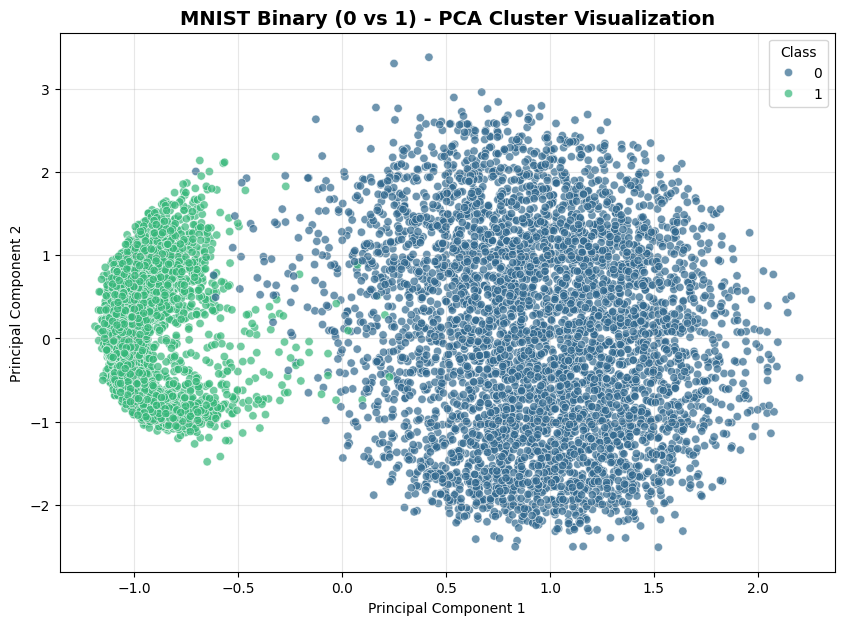

In [9]:
train_pca, _, _ = features['pca']
plt.figure(figsize=(10, 7))
sns.scatterplot(x=train_pca[:, 0], y=train_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('MNIST Binary (0 vs 1) - PCA Cluster Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.legend(title='Class')
plt.show()

## 5) KNN Model

In [10]:
# Hyperparameter Tuning for KNN
k_values = [1, 3, 5, 7, 9, 11]
all_results = {}   # method -> {k: metrics}
best_ks = {}       # method -> best k

for method in feature_methods:
    train_f, _, _ = features[method]
    print(f'\n===== {method.upper()} features =====')
    grid_results, best_params = grid_search_knn(k_values, train_f, y_train, cv=5)

    results = {}
    print(f'{"K":>3}  {"Val Accuracy":>13} {"Train Accuracy":>14}')
    print('-' * 33)
    for entry in grid_results:
        k = entry['params']['k']
        val_acc = entry['val_accuracy']
        train_acc = entry['train_accuracy']
        results[k] = {'val_accuracy': val_acc, 'train_accuracy': train_acc}
        print(f'{k:>3}  {val_acc:>13.4f} {train_acc:>14.4f}')

    all_results[method] = results
    best_ks[method] = best_params['k'] if best_params is not None else None
    bk = best_ks[method]
    print(f'Best K for {method.upper()}: {bk}  (val accuracy = {results[bk]["val_accuracy"]:.4f})')



===== FLATTEN features =====
  K   Val Accuracy Train Accuracy
---------------------------------
  1         0.9954         1.0000
  3         0.9970         1.0000
  5         0.9969         1.0000
  7         0.9967         1.0000
  9         0.9964         0.9996
 11         0.9969         0.9984
Best K for FLATTEN: 3  (val accuracy = 0.9970)

===== HOG features =====
  K   Val Accuracy Train Accuracy
---------------------------------
  1         0.9900         1.0000
  3         0.9929         0.9964
  5         0.9931         0.9932
  7         0.9940         0.9944
  9         0.9949         0.9944
 11         0.9950         0.9932
Best K for HOG: 11  (val accuracy = 0.9950)

===== PCA features =====
  K   Val Accuracy Train Accuracy
---------------------------------
  1         0.9925         1.0000
  3         0.9880         0.9972
  5         0.9812         0.9892
  7         0.9747         0.9844
  9         0.9656         0.9704
 11         0.9579         0.9624
Best K for 

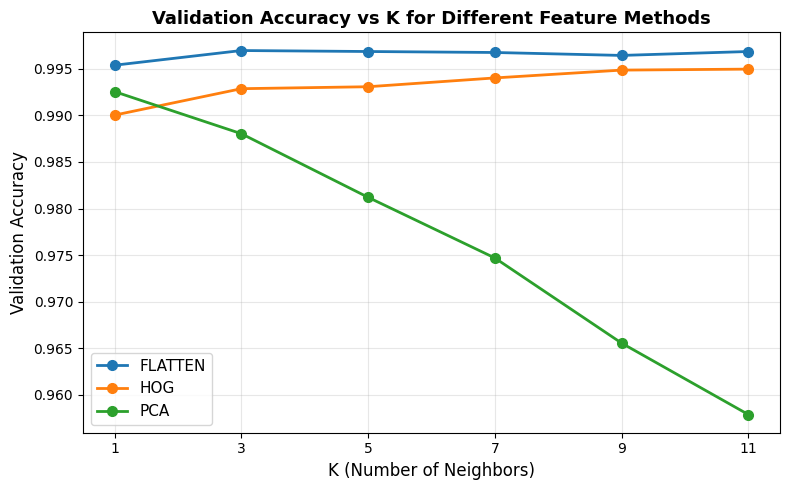

In [11]:
# Plotting validation accuracy vs K for each method
fig, ax = plt.subplots(figsize=(8, 5))
for method in feature_methods:
    accs = [all_results[method][k]['val_accuracy'] for k in k_values]
    ax.plot(k_values, accs, 'o-', label=method.upper(), linewidth=2, markersize=7)

ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Validation Accuracy vs K for Different Feature Methods', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Summary Table of Best K and Accuracies
print(f'{"Method":<10} {"K":>3}  {"Val Accuracy":>13} {"Train Accuracy":>14}')
print('-' * 45)
for method in feature_methods:
    k = best_ks[method]
    m = all_results[method][k]
    print(f'{method.upper():<10} {k:>3}  {m["val_accuracy"]:>13.4f} {m["train_accuracy"]:>14.4f}')

Method       K   Val Accuracy Train Accuracy
---------------------------------------------
FLATTEN      3         0.9970         1.0000
HOG         11         0.9950         0.9932
PCA          1         0.9925         1.0000


In [13]:
# Full K Comparison Table
for method in feature_methods:
    print(f'\n--- {method.upper()} ---')
    print(f'{"K":>3}  {"Val Accuracy":>13} {"Train Accuracy":>14}')
    for k in k_values:
        m = all_results[method][k]
        print(f'{k:>3}  {m["val_accuracy"]:>13.4f} {m["train_accuracy"]:>14.4f}')


--- FLATTEN ---
  K   Val Accuracy Train Accuracy
  1         0.9954         1.0000
  3         0.9970         1.0000
  5         0.9969         1.0000
  7         0.9967         1.0000
  9         0.9964         0.9996
 11         0.9969         0.9984

--- HOG ---
  K   Val Accuracy Train Accuracy
  1         0.9900         1.0000
  3         0.9929         0.9964
  5         0.9931         0.9932
  7         0.9940         0.9944
  9         0.9949         0.9944
 11         0.9950         0.9932

--- PCA ---
  K   Val Accuracy Train Accuracy
  1         0.9925         1.0000
  3         0.9880         0.9972
  5         0.9812         0.9892
  7         0.9747         0.9844
  9         0.9656         0.9704
 11         0.9579         0.9624


## 6) Model Evaluation and Results

In [14]:
# Final evaluation on TEST set using the best K for each method
test_results_all = {}

for method in feature_methods:
    train_f, _, test_f = features[method]
    k = best_ks[method]
    print(f'\n===== {method.upper()} (K={k}) on TEST set =====')
    model = KNNClassifier(k=k)
    model.fit(train_f, y_train)

    y_pred = model.predict(test_f)
    y_probas = model.predict_proba(test_f) if hasattr(model, 'predict_proba') else None

    result = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1_score': f1_score(y_test, y_pred, average='macro'),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'per_class_accuracy': per_class_accuracy(y_test, y_pred),
        'test_preds': y_pred,
    }

    if y_probas is not None:
        result['test_probas'] = y_probas

    test_results_all[method] = result
    print(f'  Accuracy:  {result["accuracy"]:.4f}')
    print(f'  Precision: {result["precision"]:.4f}')
    print(f'  Recall:    {result["recall"]:.4f}')
    print(f'  F1 Score:  {result["f1_score"]:.4f}')


===== FLATTEN (K=3) on TEST set =====
  Accuracy:  0.9955
  Precision: 0.9955
  Recall:    0.9955
  F1 Score:  0.9955

===== HOG (K=11) on TEST set =====
  Accuracy:  0.9941
  Precision: 0.9940
  Recall:    0.9943
  F1 Score:  0.9941

===== PCA (K=1) on TEST set =====
  Accuracy:  0.9950
  Precision: 0.9953
  Recall:    0.9948
  F1 Score:  0.9950


In [15]:
# Test Set — Comparison Table
print(f'{"Method":<10} {"K":>3}  {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('-' * 55)
for method in feature_methods:
    k = best_ks[method]
    m = test_results_all[method]
    print(f'{method.upper():<10} {k:>3}  {m["accuracy"]:>9.4f} {m["precision"]:>10.4f} {m["recall"]:>8.4f} {m["f1_score"]:>8.4f}')

Method       K   Accuracy  Precision   Recall       F1
-------------------------------------------------------
FLATTEN      3     0.9955     0.9955   0.9955   0.9955
HOG         11     0.9941     0.9940   0.9943   0.9941
PCA          1     0.9950     0.9953   0.9948   0.9950


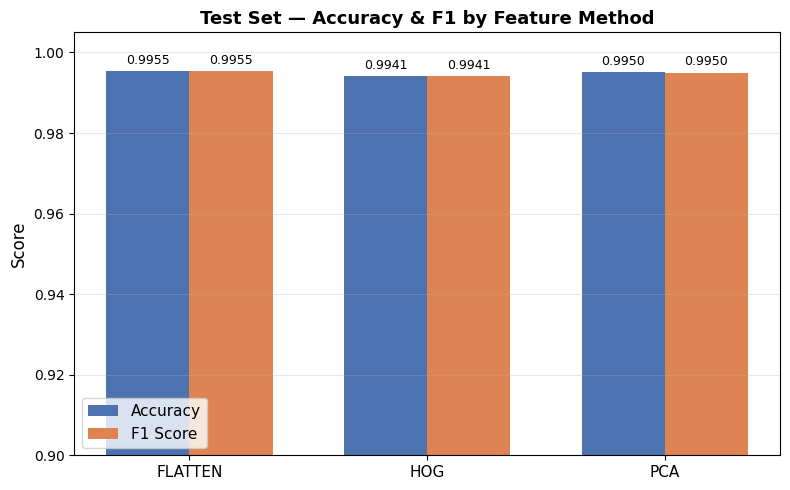

In [16]:
# Bar chart comparing Accuracy and F1 Score for each method
methods_labels = [m.upper() for m in feature_methods]
test_accs = [test_results_all[m]['accuracy'] for m in feature_methods]
test_f1s  = [test_results_all[m]['f1_score'] for m in feature_methods]

x = np.arange(len(methods_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, test_accs, width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, test_f1s, width, label='F1 Score', color='#DD8452')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Test Set — Accuracy & F1 by Feature Method', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods_labels, fontsize=11)
ax.set_ylim(0.9, 1.005)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

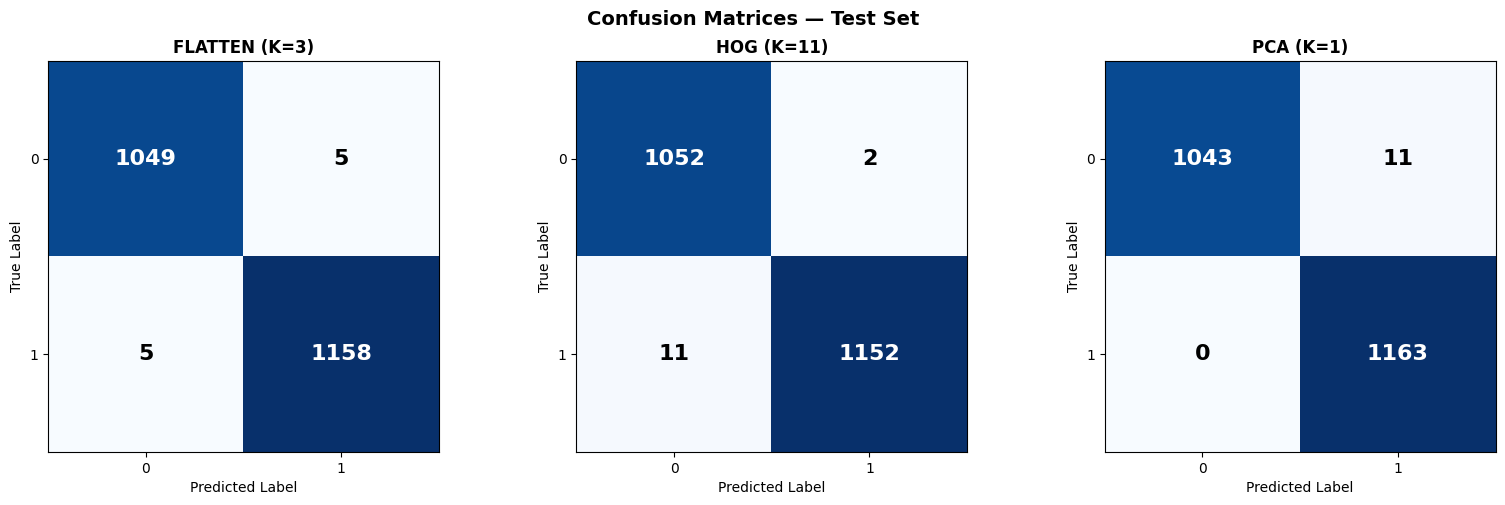

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [CLASS_A, CLASS_B]

for ax, method in zip(axes, feature_methods):
    cm = test_results_all[method]['confusion_matrix']
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{method.upper()} (K={best_ks[method]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Annotate cells with counts
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best overall: FLATTEN with K=3
Total misclassified: 10 out of 2217


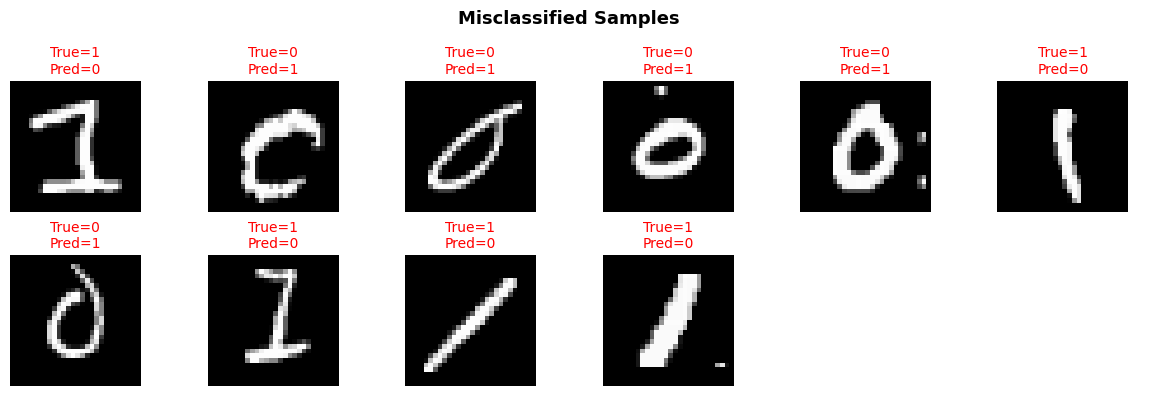

In [18]:
# Misclassified Examples

# Pick the best overall method
best_method = max(test_results_all, key=lambda m: test_results_all[m]['accuracy'])
best_k_final = best_ks[best_method]
print(f'Best overall: {best_method.upper()} with K={best_k_final}')

# Get predictions on test set with the best model
train_f, _, test_f = features[best_method]
model = KNNClassifier(k=best_k_final)
model.fit(train_f, y_train)
y_pred = model.predict(test_f)

# Find misclassified indices
misclassified = np.where(y_pred != y_test)[0]
print(f'Total misclassified: {len(misclassified)} out of {len(y_test)}')

# Show misclassified images 
n_show = len(misclassified)
if n_show > 0:
    n_cols = 6
    n_rows = (n_show + n_cols - 1) // n_cols  # Ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    axes = np.asarray(axes).flatten()
    
    for i, idx in enumerate(misclassified[:n_show]):
        axes[i].imshow(x_test[idx], cmap='gray')
        axes[i].set_title(f'True={y_test[idx]}\nPred={y_pred[idx]}', fontsize=10, color='red')
        axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    
    fig.suptitle('Misclassified Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples!')

## 7. Summary

In [ ]:
# Final summary of results
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'Classes: {CLASS_A} vs {CLASS_B}')
print(f'Train size: {len(y_train)} (balanced)  |  Val: {len(y_val)}  |  Test: {len(y_test)}')
print()
print(f'{"Method":<10} {"Best K":>6}  {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 40)
for method in feature_methods:
    k = best_ks[method]
    m = test_results_all[method]
    print(f'{method.upper():<10} {k:>6}  {m["accuracy"]:>9.4f}  {m["f1_score"]:>8.4f}')
print()

# Determine best method by F1 score
best_method = max(test_results_all, key=lambda m: test_results_all[m]['f1_score'])
best_k_final = best_ks[best_method]
print(f'Best overall: {best_method.upper()} with K={best_k_final} '
      f'(Accuracy={test_results_all[best_method]["accuracy"]:.4f})')

# Show classification report for the best model
print(f"\n\nClassification Report for {best_method.upper()} (K={best_k_final}):\n")
print(classification_report(y_test, test_results_all[best_method]['test_preds']))


FINAL SUMMARY
Classes: 0 vs 1
Train size: 9528 (balanced)  |  Val: 2217  |  Test: 2217

Method     Best K   Test Acc   Test F1
----------------------------------------
FLATTEN         3     0.9955    0.9955
HOG            11     0.9941    0.9941
PCA             1     0.9950    0.9950

Best overall: FLATTEN with K=3 (Accuracy=0.9955)


Classification Report for FLATTEN (K=3):

   precision       recall     f1-score      support

           0       0.9953       0.9953       0.9953         1054
           1       0.9957       0.9957       0.9957         1163

    accuracy                                 0.9955         2217
   macro avg       0.9955       0.9955       0.9955         2217



: 